In [1]:
import os
import pickle
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
train_videos = pickle.load(open("train_structure.pkl", "rb"))
test_videos = pickle.load(open("test_structure.pkl", "rb"))

In [3]:
def distr(dataset, labels):
    video_counts = {}
    frame_counts = {}

    for label in labels:
        # number of videos in the class
        video_counts[label] = len(dataset[label])
        
        frame_counts[label] = 0
        # total number of frames in the class
        for vid in dataset[label]:
            # print(test_videos["Abuse"][vid]["num_frames"])
            frame_counts[label] += dataset[label][vid]["num_frames"]

    return video_counts, frame_counts
    
test_video_distr, test_frame_distr = distr(test_videos, list(test_videos.keys()))
train_video_distr, train_frame_distr = distr(train_videos, list(train_videos.keys()))

In [4]:
df_train_vid = pd.DataFrame.from_dict(train_video_distr, orient='index', columns=['Train Video Count'])
df_test_vid = pd.DataFrame.from_dict(test_video_distr, orient='index', columns=['Test Video Count'])
df_train_frm = pd.DataFrame.from_dict(train_frame_distr, orient='index', columns=['Train Frame Count'])
df_test_frm = pd.DataFrame.from_dict(test_frame_distr, orient='index', columns=['Test Frame Count'])
combined_df = pd.concat(
    [df_train_vid, df_test_vid, df_train_frm, df_test_frm], 
    axis=1
)
combined_df = combined_df.reset_index().rename(columns={"index": "Activity"})

In [5]:
combined_df

,Activity,Train Video Count,Test Video Count,Train Frame Count,Test Frame Count
0,RoadAccidents,127,23,23486,2663
1,Arson,41,9,24421,2793
2,Shoplifting,29,21,24835,7623
3,Stealing,95,5,44802,1984
4,Burglary,87,13,39504,7657
5,NormalVideos,800,150,947768,64952
6,Fighting,45,5,24684,1231
7,Vandalism,45,5,13626,1111
8,Explosion,29,21,18753,6510
9,Arrest,45,5,26397,3365


In [6]:
combined_df.to_csv("stat.csv", sep=';')

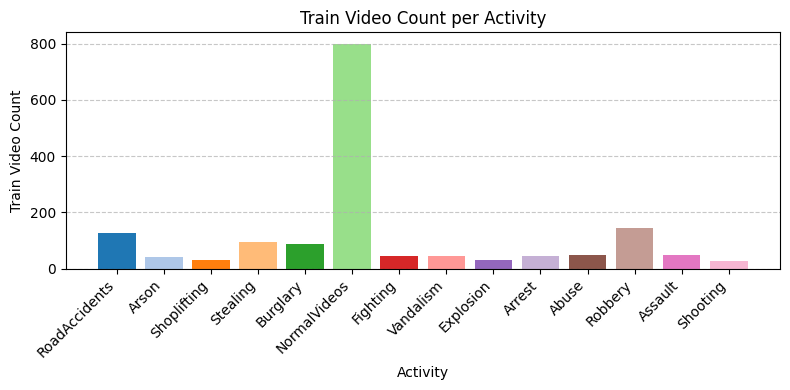

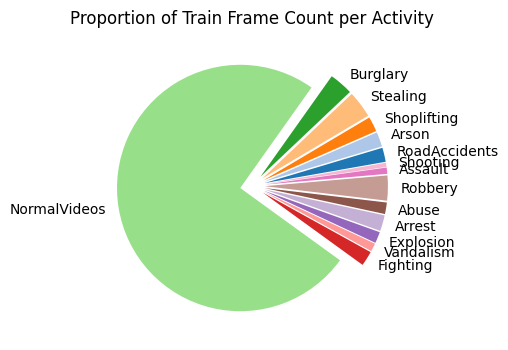

In [7]:
import matplotlib.pyplot as plt

# Train VIDEO COUNT
activities = list(combined_df["Activity"])
train_counts = list(combined_df["Train Video Count"])

colors = plt.cm.tab20.colors[:len(activities)]

fig, ax = plt.subplots(figsize=(8,4))
ax.bar(activities, train_counts, color=colors)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.xticks(rotation=45, ha='right')
ax.set_ylabel("Train Video Count")
ax.set_xlabel("Activity")
ax.set_title("Train Video Count per Activity")
plt.tight_layout()
plt.show()

# Proportion of TRAIN FRAME per Activity
explode = [0.1]*len(combined_df)

plt.figure(figsize=(4,4))
plt.pie(
    combined_df["Train Frame Count"],
    labels=combined_df["Activity"],
    startangle=10,
    colors=colors,
    explode=explode
)
plt.title("Proportion of Train Frame Count per Activity")
plt.show()

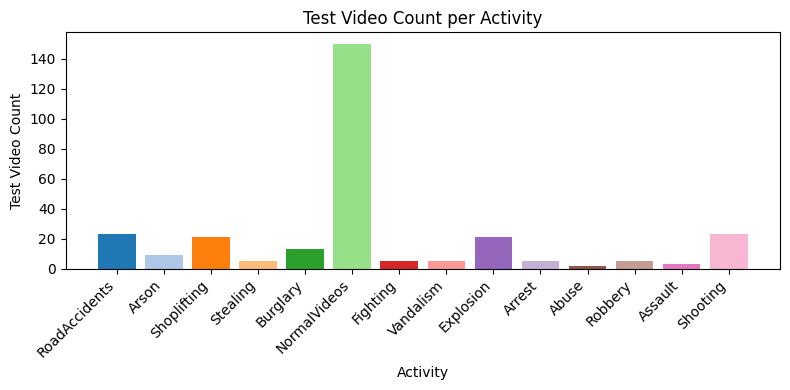

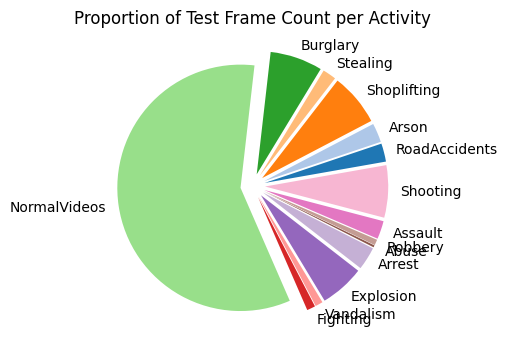

In [8]:
import matplotlib.pyplot as plt

# Test VIDEO COUNT per Activity ---
activities = list(combined_df["Activity"])
test_counts = list(combined_df["Test Video Count"])

colors = plt.cm.tab20.colors[:len(activities)]

fig, ax = plt.subplots(figsize=(8,4))
ax.bar(activities, test_counts, color=colors)

plt.xticks(rotation=45, ha='right')
ax.set_ylabel("Test Video Count")
ax.set_xlabel("Activity")
ax.set_title("Test Video Count per Activity")
plt.tight_layout()
plt.show()

# Proportion of TEST FRAME per Activity
explode = [0.1]*len(combined_df)

plt.figure(figsize=(4,4))
plt.pie(
    combined_df["Test Frame Count"],
    labels=combined_df["Activity"],
    startangle=10,
    colors=colors,
    explode=explode
)
plt.title("Proportion of Test Frame Count per Activity")
plt.show()